# Market Timing vs Time in the Market in the Long Term

In [78]:
import numpy as np
import pandas as pd

In [79]:
prices=pd.read_csv("STOXX_600_TR_daily.csv", header=0, index_col=0)
prices.head()

,Open,High,Low,Close,Volume,Adjusted
Date,,,,,,
2006-01-02,310.010010,311.410004,310.010010,311.190002,0.0,311.190002
2006-01-03,311.089996,314.320007,311.089996,313.040009,0.0,313.040009
2006-01-04,313.179993,316.140015,313.179993,316.140015,0.0,316.140015
2006-01-05,315.890015,315.950012,314.880005,315.040009,0.0,315.040009
2006-01-06,314.929993,317.100006,314.929993,317.100006,0.0,317.100006


In [80]:
prices["Returns"]=prices["Adjusted"].pct_change(fill_method=None)

In [81]:
prices=prices.ffill(limit=1)
prices=prices.dropna()
prices = prices.drop(columns=["Open", "High", "Low","Close","Volume"])

In [82]:
prices

,Adjusted,Returns
Date,,
2006-01-03,313.040009,0.005945
2006-01-04,316.140015,0.009903
2006-01-05,315.040009,-0.003479
2006-01-06,317.100006,0.006539
2006-01-09,317.709991,0.001924
...,...,...
2025-12-19,587.500000,0.003673
2025-12-22,586.750000,-0.001277
2025-12-23,588.729980,0.003374


### Now that we have our Returns column we can create our wealth index for the lump sum

In [97]:
money=50000
prices["Lump Sum"] = money * (1 + prices["Returns"]).cumprod()
prices.iloc[0, prices.columns.get_loc("Lump Sum")] = money
prices

,Adjusted,Returns,Lump Sum
Date,,,
2006-01-03,313.040009,0.005945,50000.000000
2006-01-04,316.140015,0.009903,50795.335995
2006-01-05,315.040009,-0.003479,50618.594118
2006-01-06,317.100006,0.006539,50949.581223
2006-01-09,317.709991,0.001924,51047.589730
...,...,...,...
2025-12-19,587.500000,0.003673,94182.765719
2025-12-22,586.750000,-0.001277,94062.532401
2025-12-23,588.729980,0.003374,94379.945229


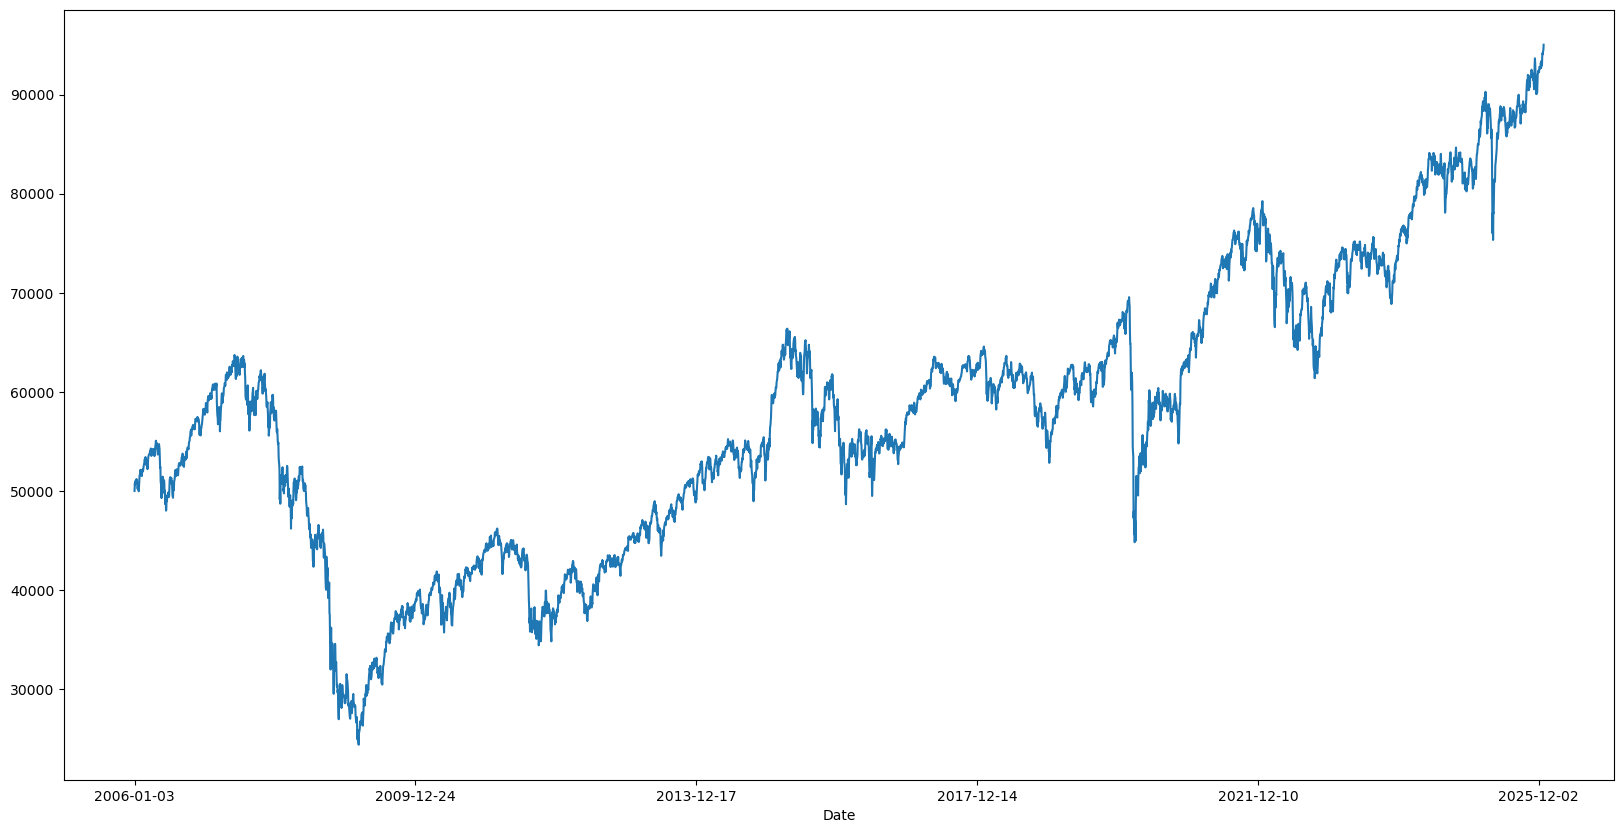

In [99]:
prices["Lump Sum"].plot(figsize=(20,10))
# Comaprison functions for later
def CAGR(wealth):
    return (wealth.iloc[-1] / wealth.iloc[0]) ** (252 / len(wealth)) - 1

def max_drawdown(wealth):
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def ann_vol(returns):
    return returns.std() * np.sqrt(252)

def sharpe(returns, rf=0):
    return (returns.mean() * 252 - rf) / (returns.std() * np.sqrt(252))

In [114]:
# Stats for portfolio lump sum
cagr_lump=CAGR(prices["Lump Sum"])
print("CAGR of Lump Sum Portfolio --> ", cagr_lump*100,"%")
tot_return_lump=(prices["Lump Sum"].iloc[-1] - prices["Lump Sum"].iloc[0])/(prices["Lump Sum"].iloc[0])
print("Total Return of Lump Sum Portfolio --> ", tot_return_lump*100,"%")

CAGR of Lump Sum Portfolio -->  3.2774464720413565 %
Total Return of Lump Sum Portfolio -->  90.05842594794157 %


In [112]:
a=prices.iloc[0]

In [113]:
a

Adjusted      313.040009
Returns         0.005945
Lump Sum    50000.000000
Name: 2006-01-03, dtype: float64